In [27]:
import os
import time
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from skimage.feature import local_binary_pattern,graycomatrix,graycoprops,hog
from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve,StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix

## Settings

The dataset folders paper/, glass/, plastic/ should live in the project root next to this notebook.

In [28]:
IMG_SIZE = 224
CLASSES = ["paper","glass","plastic"]
DATA_DIR = "."
MODELS_DIR = "models"
RANDOM_STATE = 42

os.makedirs(MODELS_DIR,exist_ok=True)

## Preprocessing helpers

In [29]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Cannot read image: "+path)
    return img

def resize_img(img,size=IMG_SIZE):
    return cv2.resize(img,(size,size))

def to_gray(img):
    return cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

def to_hsv(img):
    return cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

## Feature extraction

- Color histogram (BGR+HSV, 32 bins per channel)
- Color moments (mean/std/skewness per channel for BGR and HSV)
- LBP (Local Binary Pattern, P=24 R=3, uniform)
- GLCM (quantized to 8 levels, 5 props x 2 distances x 4 angles)
- HOG (9 orientations, 32x32 cells, 2x2 blocks)
- Edge density (Canny edge ratio + Sobel magnitude stats)
- Specular highlights (bright low-saturation reflection stats)
- Spatial-pyramid region color (HSV hist over whole image + 2x2 quadrants)

In [ ]:
def color_hist(img):
    #count how many pixels have each color
    feats = []
    #normal bgr channels
    for c in range(3):
        h = cv2.calcHist([img],[c],None,[32],[0,256]).flatten()
        h = h/(h.sum()+1e-7) #make it a fraction so big/small images compare fairly (+1e-7 = avoid /0)
        feats.append(h)
    #HSV channels too (describes color better than raw RGB)
    hsv = to_hsv(img)
    ranges = [(0,180),(0,256),(0,256)] #hue maxes at 180 in opencv, not 256
    for c,r in enumerate(ranges):
        h = cv2.calcHist([hsv],[c],None,[32],list(r)).flatten()
        h = h/(h.sum()+1e-7)
        feats.append(h)
    return np.concatenate(feats)

def color_moments(img):
    #3 simple stats per channel: average color, how spread out, and lopsidedness
    hsv = to_hsv(img)
    feats = []
    for src in (img,hsv):
        for c in range(3):
            ch = src[:,:,c].astype("float32")
            m = ch.mean() #average
            s = ch.std()+1e-7 #spread (+1e-7 so the divide below never blows up)
            sk = float(np.mean(((ch-m)/s)**3)) #skewness: is the spread tilted to one side
            feats.extend([float(m)/255.0,float(s)/255.0,sk]) #/255 -> keep numbers ~0..1
    return np.asarray(feats,dtype="float32")

def lbp_hist(gray):
    #compare each pixel to its neighbors -> a texture code, then count the codes.
    #captures rough vs smooth surface.
    P,R = 24,3 #24 neighbor points, radius 3
    lbp = local_binary_pattern(gray,P,R,method="uniform")
    hist,_ = np.histogram(lbp.ravel(),bins=P+2,range=(0,P+2)) #P+2 buckets is the standard for "uniform" LBP
    hist = hist.astype("float32")
    hist /= (hist.sum()+1e-7)
    return hist

def glcm_feat(gray):
    g = (gray//32).astype(np.uint8) #drop 256 gray levels to 8, otherwise this is slow
    distances = [1,2]
    angles = [0,np.pi/4,np.pi/2,3*np.pi/4] #4 directions: -, /, |, \
    glcm = graycomatrix(g,distances=distances,angles=angles,levels=8,symmetric=True,normed=True)
    props = ["contrast","dissimilarity","homogeneity","energy","correlation"]
    out = []
    for p in props:
        out.append(graycoprops(glcm,p).flatten()) #a texture score for each direction+distance
    return np.concatenate(out).astype("float32")

def hog_feat(gray):
    #which way the edges point, summed up over 32x32 squares = the object's shape.
    #this is the biggest block (~1296 numbers). kept at 32 on purpose: smaller
    #squares blew it up and the model just memorized the training images.
    return hog(
        gray,
        orientations=9, #9 edge-direction bins
        pixels_per_cell=(32,32),
        cells_per_block=(2,2),
        block_norm="L2-Hys",
        feature_vector=True,
    ).astype("float32")

def edge_feat(gray):
    #just: how busy/edgy is the picture
    edges = cv2.Canny(gray,80,160)
    edge_ratio = float(edges.mean())/255.0 #fraction of the image that is edge pixels
    gx = cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3) #edge strength sideways
    gy = cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3) #edge strength up/down
    mag = np.sqrt(gx*gx+gy*gy) #total edge strength at each pixel
    return np.asarray([
        edge_ratio,
        float(mag.mean())/255.0,
        float(mag.std())/255.0,
        float(np.percentile(mag,90))/255.0, #how strong the strongest 10% of edges are
    ],dtype="float32")

def specular_feat(img):
    #the glass-vs-plastic trick. glass is shiny + see-through so it has bright
    #spots that aren't colorful (just white glare). plastic is more solid color.
    hsv = to_hsv(img)
    s = hsv[:,:,1].astype("float32") #saturation = how colorful
    v = hsv[:,:,2].astype("float32") #value = how bright
    spec = ((v > 230) & (s < 50)).astype("uint8") #bright but not colorful = a glare spot
    n_comp,_ = cv2.connectedComponents(spec) #how many separate glare spots
    v_sorted = np.sort(v.ravel())
    top1 = v_sorted[int(0.99*v_sorted.size):] #keep only the brightest 1% of pixels
    return np.asarray([
        float(spec.mean()), #how much of the image is glare
        float((v > 240).mean()), #how much is very bright
        float(top1.mean())/255.0, #how bright those brightest pixels get
        float(v.mean())/255.0,
        float(v.std())/255.0,
        float(s.mean())/255.0, #glass usually low color, plastic higher
        float(s.std())/255.0,
        min(n_comp-1,200)/200.0, #many tiny glare spots -> likely glass (capped at 200)
    ],dtype="float32")

def region_color(img):
    #same as color_hist but split the image into 5 areas (whole + 4 quarters).
    #point: where the color is matters - a plastic bottle's label/cap sits in
    #one spot, clear glass is empty in the middle. plain color_hist loses that.
    hsv = to_hsv(img)
    H,W = hsv.shape[:2]
    hy,hx = H//2,W//2 #halfway point, used to cut into quarters
    regions = [
        (0,0,H,W), #whole image
        (0,0,hy,hx),(0,hx,hy,W),(hy,0,H,hx),(hy,hx,H,W), #top-L, top-R, bot-L, bot-R
    ]
    chans = [(0,12,180),(1,12,256),(2,6,256)] #(which channel, how many buckets, its max value)
    feats = []
    for (y0,x0,y1,x1) in regions:
        sub = hsv[y0:y1,x0:x1] #crop to just this area
        for c,bins,rng in chans:
            h = cv2.calcHist([sub],[c],None,[bins],[0,rng]).flatten()
            h = h/(h.sum()+1e-7)
            feats.append(h.astype("float32"))
    return np.concatenate(feats)

def extract_features(img):
    #the main function: run all the blocks above and stick them into one big list
    img = resize_img(img)
    gray = to_gray(img)
    return np.concatenate([
        color_hist(img),
        color_moments(img),
        lbp_hist(gray),
        glcm_feat(gray),
        hog_feat(gray),
        edge_feat(gray),
        specular_feat(img),
        region_color(img),
    ]).astype("float32")

#sanity check: run a blank image through and see how many numbers each block
#makes. the pipeline cell below needs these sizes to know which columns are HOG.
_d = resize_img(np.zeros((224,224,3),dtype=np.uint8))
_g = to_gray(_d)
BLOCK_SIZES = {
    "color_hist":     color_hist(_d).shape[0],
    "color_moments":  color_moments(_d).shape[0],
    "lbp":            lbp_hist(_g).shape[0],
    "glcm":           glcm_feat(_g).shape[0],
    "hog":            hog_feat(_g).shape[0],
    "edge":           edge_feat(_g).shape[0],
    "specular":       specular_feat(_d).shape[0],
    "region_color":   region_color(_d).shape[0],
}
print("Block sizes:",BLOCK_SIZES)
print("Feature vector size:",sum(BLOCK_SIZES.values()))

## Augmentation (training set only)

In [ ]:
def augment(img,seed):
    #make fake extra training photos from one photo so the model learns the
    #object, not the exact picture. only used on training data.
    rng = np.random.default_rng(seed) #seed -> same "random" each run, so results are repeatable
    h,w = img.shape[:2]
    variants = []

    #1. mirror it left-right
    variants.append(cv2.flip(img,1))

    #2. rotate a random small angle (-20 to 20 deg)
    angle = float(rng.uniform(-20,20))
    M = cv2.getRotationMatrix2D((w/2,h/2),angle,1.0)
    variants.append(cv2.warpAffine(img,M,(w,h),borderMode=cv2.BORDER_REFLECT)) #REFLECT = fill empty corners by mirroring, no ugly black border

    #3. zoom in or out by up to 10%
    factor = float(rng.uniform(0.9,1.1))
    if factor >= 1.0:
        #zoom in: crop a smaller center then stretch it back to full size
        nh,nw = max(1,int(h/factor)),max(1,int(w/factor))
        y0,x0 = (h-nh)//2,(w-nw)//2
        crop = img[y0:y0 + nh,x0:x0 + nw]
        variants.append(cv2.resize(crop,(w,h)))
    else:
        #zoom out: shrink it and paste it centered on a black canvas
        sw,sh = max(1,int(w*factor)),max(1,int(h*factor))
        scaled = cv2.resize(img,(sw,sh))
        canvas = np.zeros_like(img)
        y0,x0 = (h-sh)//2,(w-sw)//2
        canvas[y0:y0 + sh,x0:x0 + sw] = scaled
        variants.append(canvas)

    #4. make it brighter/darker
    beta = int(rng.uniform(-30,30)) #beta is added to every pixel
    variants.append(cv2.convertScaleAbs(img,alpha=1.0,beta=beta))

    #5. change contrast (different cameras/lighting). helps the glass-vs-plastic case.
    alpha = float(rng.uniform(0.7,1.3)) #alpha multiplies every pixel
    variants.append(cv2.convertScaleAbs(img,alpha=alpha,beta=0))

    #6. slight blur, like a not-quite-focused phone photo
    k = int(rng.choice([3,5])) #blur strength (must be an odd number)
    variants.append(cv2.GaussianBlur(img,(k,k),0))

    return variants

## Load dataset paths

In [32]:
paths = []
labels = []
for cls in CLASSES:
    d = Path(DATA_DIR)/cls
    if not d.is_dir():
        raise FileNotFoundError("Missing class folder: " + str(d))
    files = sorted([str(p) for p in d.iterdir() if p.suffix.lower() == ".jpg"])
    print(cls, "->", len(files), "images")
    paths.extend(files)
    labels.extend([cls]*len(files))

print("Total:", len(paths), "images")

paper -> 594 images
glass -> 501 images
plastic -> 482 images
Total: 1577 images


## Train/Val/Test split (70/15/15)

In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(labels) #turn "paper"/"glass"/"plastic" into numbers 0/1/2
paths_arr = np.array(paths)

#first cut off 15% for the final exam (test). stratify = keep the 3 classes
#balanced in every split so one split isn't accidentally all paper.
p_tv,p_test,y_tv,y_test_lbl = train_test_split(
    paths_arr,y_all,test_size=0.15,stratify=y_all,random_state=RANDOM_STATE
)
#from the remaining 85%, take 15% (of the total) for validation, rest is train.
#0.15/0.85 because we're now splitting the leftover 85%, not the whole thing.
p_train,p_val,y_train_lbl,y_val_lbl = train_test_split(
    p_tv,y_tv,test_size=0.15/0.85,stratify=y_tv,random_state=RANDOM_STATE
)

print("train:",len(p_train),"  val:",len(p_val),"  test:",len(p_test))

## Extract features for all splits

Training set is augmented (5x),val/test are plain. This is the slow step.

In [ ]:
from joblib import Parallel,delayed

def _process_one(p,lbl,do_augment,seed):
    #turn one image file into feature rows. if augmenting, also do its 6 fakes.
    img = load_image(p)
    feats = [extract_features(img)]
    labels = [int(lbl)]
    if do_augment:
        for aug_img in augment(img,seed=seed):
            feats.append(extract_features(aug_img))
            labels.append(int(lbl))
    return feats,labels

def build_features(paths_list,labels_list,do_augment,seed_base=0):
    #runs the above on every image, in parallel (all CPU cores) since it's slow.
    #also returns groups: a tag saying which original photo each row came from.
    #why groups matter: an image + its 6 fakes look almost identical. if some
    #land in training and some in testing during cross-validation, the score
    #looks great but is fake. groups keep them together.
    t0 = time.time()
    results = Parallel(n_jobs=-1,verbose=5)( #n_jobs=-1 = use every CPU core
        delayed(_process_one)(p,lbl,do_augment,seed_base + i)
        for i,(p,lbl) in enumerate(zip(paths_list,labels_list))
    )
    feats,out_labels,groups = [],[],[]
    for gid,(f,l) in enumerate(results): #gid = the "which original photo" id
        feats.extend(f)
        out_labels.extend(l)
        groups.extend([gid]*len(f)) #same id for the photo and all its fakes
    print("  done in",round(time.time()-t0,1),"s")
    return np.vstack(feats),np.asarray(out_labels),np.asarray(groups)

print("Train features (with augmentation)...")
X_train,y_train,g_train = build_features(p_train,y_train_lbl,do_augment=True) #only training gets fakes

print("Val features...")
X_val,y_val,_ = build_features(p_val,y_val_lbl,do_augment=False)

print("Test features...")
X_test,y_test,_ = build_features(p_test,y_test_lbl,do_augment=False)

print("X_train:",X_train.shape," X_val:",X_val.shape," X_test:",X_test.shape)
print("source-image groups in train:",len(np.unique(g_train)))

## Train SVM (per-block transform + GridSearchCV)

In [ ]:
#work out which columns of the feature vector belong to which block.
#we build it from BLOCK_SIZES so if a block changes size, this still lines up.
_order = ["color_hist","color_moments","lbp","glcm","hog","edge","specular","region_color"]
_bounds = {}
_pos = 0
for _name in _order:
    _bounds[_name] = (_pos, _pos + BLOCK_SIZES[_name]) #(start col, end col) for this block
    _pos += BLOCK_SIZES[_name]

hog_lo,hog_hi = _bounds["hog"]
hog_idx  = list(range(hog_lo,hog_hi)) #the columns that are HOG
rest_idx = [i for i in range(_pos) if not (hog_lo <= i < hog_hi)] #everything that's not HOG
print(f"HOG cols: {len(hog_idx)}   non-HOG (colour/texture/specular/region) cols: {len(rest_idx)}")

def make_ct(hog_n_components):
    #the key idea. HOG is ~1296 numbers vs ~438 for everything else, so if we
    #treat them all the same, HOG drowns out color/glare. so: shrink HOG on its
    #own (PCA = squeeze many related numbers into a few), keep the rest at full
    #strength. earlier versions skipped this and accuracy crashed to 0.70.
    return ColumnTransformer([
        ("hog", Pipeline([
            ("sc", StandardScaler()), #put all HOG numbers on the same scale first
            ("pca", PCA(n_components=hog_n_components,whiten=True,
                        svd_solver="randomized",random_state=RANDOM_STATE)), #squeeze HOG down
        ]), hog_idx),
        ("rest", StandardScaler(), rest_idx), #everything else: just rescale, keep all of it
    ])

pipe = Pipeline([
    ("feat", make_ct(200)), #200 is just a placeholder, the grid below tries several
    ("svm", SVC(
        kernel="rbf", #rbf = can draw curved boundaries between classes
        decision_function_shape="ovo", #one-vs-one: compare classes in pairs
        probability=False, #off = faster while searching, turned on once at the end
        cache_size=1000, #MB of memory for the SVM, bigger = faster here
        random_state=RANDOM_STATE,
    )),
])

#try lots of settings and keep the best. last run picked the biggest HOG size
#and a middle C (both at the edge of the old range) so we widen the range.
#4 x 4 x 3 = 48 combos, each tested 5 ways = 240 fits (this is the slow cell).
param_grid = {
    "feat__hog__pca__n_components": [200,350,500,700], #how much HOG detail to keep
    "svm__C": [10,30,100,300], #how hard the SVM tries to fit (too high = memorize)
    "svm__gamma": ["scale",0.01,0.02], #how wiggly the boundary can be
    "svm__class_weight": ["balanced"],
}

#5-fold cross-validation, but grouped by original photo so a
#photo and its fakes never end up on both sides -> honest score.
cv = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

grid = GridSearchCV(pipe,param_grid,cv=cv,scoring="f1_macro",n_jobs=-1,verbose=1) #f1_macro = the proposal's main metric
t0 = time.time()
grid.fit(X_train,y_train,groups=g_train)
print("GridSearch wall time:",round(time.time()-t0,1),"s")

print("Best params:",grid.best_params_)
print("Best CV f1_macro:",round(grid.best_score_,4))

best_pipe = grid.best_estimator_ #the winning settings, already trained
print("Val accuracy: ",round(best_pipe.score(X_val,y_val),4))
print("Test accuracy:",round(best_pipe.score(X_test,y_test),4)) #the real number that counts

## Evaluate on test set

Classification report + confusion matrix.

              precision    recall  f1-score   support

       glass     0.8800    0.8800    0.8800        75
       paper     0.9239    0.9551    0.9392        89
     plastic     0.8714    0.8356    0.8531        73

    accuracy                         0.8945       237
   macro avg     0.8918    0.8902    0.8908       237
weighted avg     0.8939    0.8945    0.8940       237



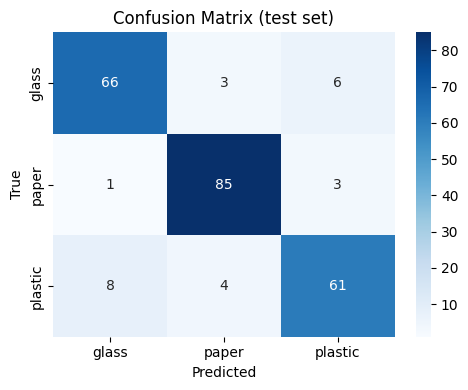

In [36]:
y_pred = best_pipe.predict(X_test)
target_names = list(le.classes_)

report = classification_report(y_test,y_pred,target_names=target_names,digits=4)
print(report)

#save report to a text file too
with open(os.path.join(MODELS_DIR,"classification_report.txt"),"w",encoding="utf-8") as f:
    f.write(report)

cm = confusion_matrix(y_test,y_pred)
fig,ax = plt.subplots(figsize=(5,4))
sns.heatmap(
    cm,annot=True,fmt="d",cmap="Blues",
    xticklabels=target_names,yticklabels=target_names,ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR,"confusion_matrix.png"),dpi=150)
plt.show()

## Inference latency

In [ ]:
#time each step of making one prediction, to check we're under the speed limit.
#this is exactly what app.py does for every uploaded photo.
stage_keys = ["load","preproc","color_hist","color_moments",
              "lbp","glcm","hog","edge","specular","region","scale_predict","total"]
stage_times = {k: [] for k in stage_keys}

for p in p_test:
    t_start = time.perf_counter()

    t0 = time.perf_counter()
    img = load_image(p)
    stage_times["load"].append((time.perf_counter()-t0)*1000) #*1000 = seconds to milliseconds

    t0 = time.perf_counter()
    img_r = resize_img(img)
    gray = to_gray(img_r)
    stage_times["preproc"].append((time.perf_counter()-t0)*1000)

    #time every feature block separately so we can see which one is slow
    t0 = time.perf_counter(); ch = color_hist(img_r); stage_times["color_hist"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); cm = color_moments(img_r); stage_times["color_moments"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); lb = lbp_hist(gray); stage_times["lbp"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); gl = glcm_feat(gray); stage_times["glcm"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); hg = hog_feat(gray); stage_times["hog"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); ed = edge_feat(gray); stage_times["edge"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); sp = specular_feat(img_r); stage_times["specular"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); rc = region_color(img_r); stage_times["region"].append((time.perf_counter()-t0)*1000)

    feats = np.concatenate([ch,cm,lb,gl,hg,ed,sp,rc]).astype("float32").reshape(1,-1) #glue blocks, shape (1, N) for one sample

    t0 = time.perf_counter()
    _ = best_pipe.predict(feats) #the trained model's actual guess
    stage_times["scale_predict"].append((time.perf_counter()-t0)*1000)

    stage_times["total"].append((time.perf_counter()-t_start)*1000)

latencies = np.array(stage_times["total"])

print("="*56)
print("  INFERENCE SPEED (milliseconds,per image,test set)")
print("="*56)
print(f"{'stage':<16} {'mean':>8} {'median':>8} {'p95':>8} {'max':>8}")
print("-"*56)
for k in stage_keys:
    arr = np.array(stage_times[k])
    #mean=average, median=typical, p95=slow-ish case, max=worst case
    print(f"{k:<16} {arr.mean():>8.2f} {np.median(arr):>8.2f} "
          f"{np.percentile(arr,95):>8.2f} {arr.max():>8.2f}")
print("="*56)
print(f"  >> Total inference speed: {latencies.mean():.2f} ms/image  "
      f"(~{1000.0/latencies.mean():.1f} FPS)")
print("="*56)
print()
print("Proposal target: <=200 ms (min),<=100 ms (ideal)")
print("Pass min target:  ","YES" if latencies.mean() <= 200 else "NO")
print("Pass ideal target:","YES" if latencies.mean() <= 100 else "NO")

##  Learning curve (Accuracy)

In [ ]:
#learning curve: train the model on more and more data and see how train vs
#cross-val accuracy move. if they meet high = good. big gap = overfitting.
lc_cv = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
sizes,train_scores,val_scores = learning_curve(
    best_pipe,X_train,y_train,groups=g_train,cv=lc_cv,
    train_sizes=np.linspace(0.2,1.0,4), #try 20%, 47%, 73%, 100% of the training data
    scoring="accuracy",n_jobs=-1,
)
tm,ts = train_scores.mean(axis=1),train_scores.std(axis=1) #mean line + spread, for train
vm,vs = val_scores.mean(axis=1),val_scores.std(axis=1) #same for cross-val

fig,ax = plt.subplots(figsize=(7,5))
ax.plot(sizes,tm,"o-",label="Train accuracy")
ax.fill_between(sizes,tm-ts,tm + ts,alpha=0.2) #shaded band = how much it wobbled
ax.plot(sizes,vm,"o-",label="CV accuracy")
ax.fill_between(sizes,vm-vs,vm + vs,alpha=0.2)
ax.set_xlabel("Training examples")
ax.set_ylabel("Accuracy")
ax.set_title("Learning curve-Accuracy (RBF SVM,grouped 5-fold CV)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR,"learning_curve.png"),dpi=150)
plt.show()

## Save model

In [ ]:
#the grid search ran with probability=False for speed. now retrain once, with
#the winning settings, and probability=True so the app can show confidence %.
prob_pipe = Pipeline([
    ("feat", make_ct(grid.best_params_["feat__hog__pca__n_components"])), #reuse the winning HOG size
    ("svm", SVC(
        kernel="rbf",
        C=grid.best_params_["svm__C"],
        gamma=grid.best_params_["svm__gamma"],
        class_weight=grid.best_params_.get("svm__class_weight"),
        probability=True,
        cache_size=1000,
        decision_function_shape="ovo",
        random_state=RANDOM_STATE,
    )),
])
prob_pipe.fit(X_train,y_train)

#save the whole thing as one file. app.py just loads this and calls it -
#no need to keep separate scaler/pca/svm files in sync by hand anymore.
joblib.dump(prob_pipe,os.path.join(MODELS_DIR,"pipeline.joblib"))
joblib.dump(le,os.path.join(MODELS_DIR,"label_encoder.joblib")) #the 0/1/2 <-> name mapping
joblib.dump({"X_test": X_test,"y_test": y_test},os.path.join(MODELS_DIR,"test_split.joblib"))

#delete leftover files from the old design so app.py can't load the wrong thing
for _old in ("svm_model.joblib","scaler.joblib","pca.joblib"):
    _p = os.path.join(MODELS_DIR,_old)
    if os.path.exists(_p):
        os.remove(_p)

print("Saved pipeline.joblib (ColumnTransformer -> SVC) to",MODELS_DIR)
#load it back and re-check the test score, to prove the saved file actually works
print("Sanity -- test accuracy from reloaded pipeline:",
      round(joblib.load(os.path.join(MODELS_DIR,"pipeline.joblib")).score(X_test,y_test),4))